<a href="https://colab.research.google.com/github/biglalo104/Projects/blob/main/Time%20Series%20Forecasting%20in%20Financial%20Markets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error
import math
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
#1.Data Preparation
def get_stock_data(ticker="AAPL",start="2015-01-01",end="2023-10-01"):
  print(f"Downloading data for {ticker}...")
  df=yf.download(ticker,start=start,end=end,progress=False)
  #Handle potential Multilndex columns from newer yfinance versions
  if isinstance(df.columns,pd.MultiIndex):
    df=df.droplevel(1,axis=1)
  data = df['Close'].values.reshape(-1,1)
  return data

def create_sequences(data,seq_length=30):
  "Creates time series sequences:X=[t-30..t-1],Y=[t]"
  xs,ys=[],[]
  for i in range(len(data)-seq_length):
    x=data[i:(i+seq_length)]
    y=data[i+seq_length]
    xs.append(x)
    ys.append(y)
  return np.array(xs),np.array(ys)

class StockDataset(Dataset):
  def __init__(self,X,y):
    self.X=torch.tensor(X,dtype=torch.float32)
    self.y=torch.tensor(y,dtype=torch.float32).view(-1,1)

  def __len__(self):
    return len(self.X)

  def __getitem__(self,idx):
    return self.X[idx],self.y[idx]


In [5]:
#2.Model Impelementation
class LSTMModel(nn.Module):
  def __init__(self,input_size=1,hidden_size=64,num_layers=2,dropout=0.2):
    super(LSTMModel,self).__init__()
    self.hidden_size=hidden_size
    self.num_layers=num_layers

    #LSTM Layer
    self.lstm=nn.LSTM(input_size,hidden_size,num_layers,
                      batch_first=True,dropout=dropout)
    #Fully connected layer to predict the next value
    self.fc=nn.Linear(hidden_size,1)

  def forward(self,x):
    #Initialize hidden state with zeros
    h0=torch.zeros(self.num_layers,x.size(0),self.hidden_size).to(x.device)
    c0=torch.zeros(self.num_layers,x.size(0),self.hidden_size).to(x.device)

    #Forward propagate LSTM
    out,_=self.lstm(x,(h0,c0))
    #Decode the hidden state of the last time step
    out=self.fc(out[:,-1,:])
    return out


Starting training..
Epoch[10/50],Loss:0.000372
Epoch[20/50],Loss:0.000306
Epoch[30/50],Loss:0.000283
Epoch[40/50],Loss:0.000299
Epoch[50/50],Loss:0.000217

Evaluating on Test Set...

---Final Performance Metrics----
Mean Squared Error(MSE):17.5507
Root Mean Squared Error(RMSE):4.19
Mean Absolute Error(MAE):3.40
Plot saved to 'forecast_results.png


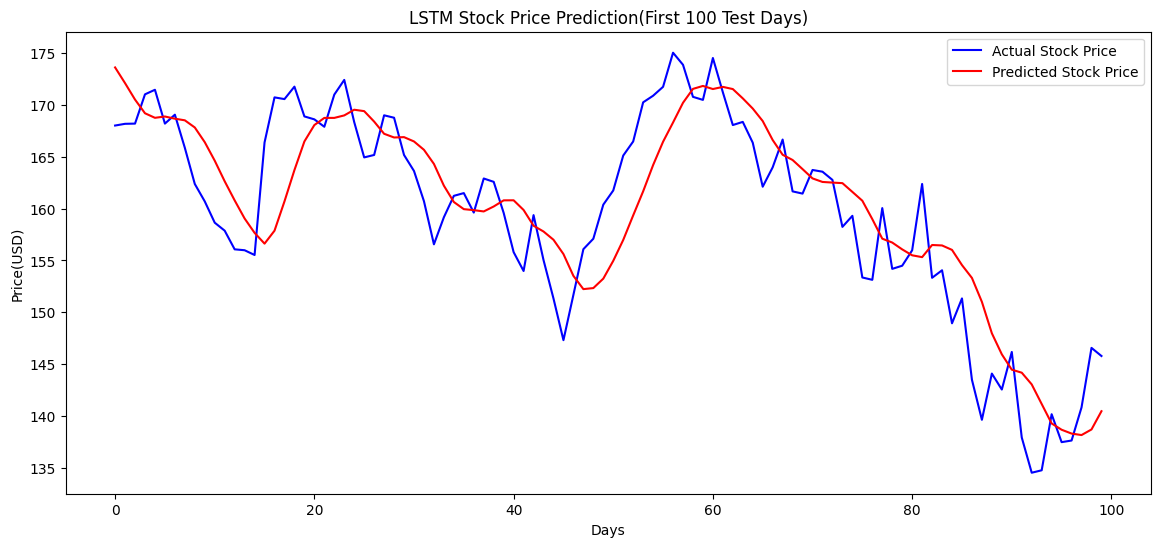

In [7]:
#3.Training and Evaluation
def train_model(model,train_loader,criterion,optimizer,epochs=50):
  model.train()
  for epoch in range(epochs):
    epoch_loss=0
    for X_batch,y_batch in train_loader:
      optimizer.zero_grad()
      outputs=model(X_batch)
      loss=criterion(outputs,y_batch)
      loss.backward()
      optimizer.step()
      epoch_loss+=loss.item()

    if(epoch+1)%10==0:
      print(f'Epoch[{epoch+1}/{epochs}],Loss:{epoch_loss/len(train_loader):.6f}')

def evaluate_model(model,test_loader,scaler):
  model.eval()
  predictions=[]
  actuals=[]

  with torch.no_grad():
    for X_batch,y_batch in test_loader:
      preds = model(X_batch)
      predictions.extend(preds.numpy())
      actuals.extend(y_batch.numpy())

  predictions=np.array(predictions)
  actuals=np.array(actuals)

  #Inverse transform to get actual dollar prices
  pred_prices=scaler.inverse_transform(predictions)
  actual_prices=scaler.inverse_transform(actuals)

  mse=mean_squared_error(actual_prices,pred_prices)
  rmse=math.sqrt(mse)
  mae=mean_absolute_error(actual_prices,pred_prices)

  return pred_prices,actual_prices,mse,rmse,mae

def main():
  #Hyperparameter
  SEQ_LENGTH=30 #Lookback window(30days)
  BATCH_SIZE=32
  EPOCHS=50
  LR=0.001

  #Data Prep
  raw_data=get_stock_data("AAPL","2015-01-01","2023-10-01")

  #Scale data between 0 and 1(Crucial for LSTMS)
  scaler = MinMaxScaler(feature_range=(0,1))
  scaled_data=scaler.fit_transform(raw_data)

  # Create sequences
  X,y = create_sequences(scaled_data,SEQ_LENGTH)
  #Train/Test Split(Chronologocal,no shuffling for time-series!)
  train_size=int(len(X)*0.8)
  X_train,X_test=X[:train_size],X[train_size:]
  y_train,y_test=y[:train_size],y[train_size:]


  train_dataset=StockDataset(X_train,y_train)
  test_dataset=StockDataset(X_test,y_test)

  train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
  test_loader=DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False)

  #2.Model Setup
  model=LSTMModel(input_size=1,hidden_size=64,num_layers=2,dropout=0.2)
  criterion=nn.MSELoss()
  optimizer=torch.optim.Adam(model.parameters(),lr=LR)

  #Train
  print("Starting training..")
  train_model(model,train_loader,criterion,optimizer,epochs=EPOCHS)

  #4.Evaluate
  print("\nEvaluating on Test Set...")
  pred_prices,actual_prices,mse,rmse,mae=evaluate_model(model,test_loader,scaler)

  print("\n---Final Performance Metrics----")
  print(f"Mean Squared Error(MSE):{mse:.4f}")
  print(f"Root Mean Squared Error(RMSE):{rmse:.2f}")
  print(f"Mean Absolute Error(MAE):{mae:.2f}")

  #5.Plotting (Optional,saves to file)
  plt.figure(figsize=(14,6))
  #Plotting a subset of test data for clarity
  plt.plot(actual_prices[:100],color='blue',label='Actual Stock Price')
  plt.plot(pred_prices[:100],color='red',label='Predicted Stock Price')
  plt.title('LSTM Stock Price Prediction(First 100 Test Days)')
  plt.xlabel('Days')
  plt.ylabel('Price(USD)')
  plt.legend()
  plt.savefig('forecast_results.png')
  print("Plot saved to 'forecast_results.png")

if __name__ == '__main__':
  main()
